
## ***Meta-Data (About Dataset) :***
- The data have `891` entries on train dataset and `418` on test dataset
- `12` columns in train_csv and `11` columns in test_csv

##### ***Variable Definition	Key***
- **survived**	Survival	0 = No, 1 = Yes
- **pclass**	Ticket class	1 = 1st, 2 = 2nd, 3 = 3rd
- **sex**	male , female
- **Age**	Age in years
- **sibsp**	# of siblings / spouses aboard the Titanic
- **parch**	# of parents / children aboard the Titanic
- **ticket**	Ticket number
- **fare**	Passenger fare
- **cabin**	Cabin number
- **embarked**	Port of Embarkation	C = Cherbourg, Q = Queenstown, S = Southampton
##### ***Variable Notes***
- ***pclass***: A proxy for socio-economic status (SES)
1st = Upper
2nd = Middle
3rd = Lower
- ***Age***: Age is fractional if less than 1. If the age is estimated, is it in the form of xx.5
- ***Sibsp***: The dataset defines family relations in this way
- Sibling  brother, sister, stepbrother, stepsister
- Spouse  husband, wife (mistresses and fiancés were ignored)

- ***parch***: The dataset defines family relations in this way
- ***Parent*** mother, father
- ***Child***  daughter, son, stepdaughter, stepson

Some children travelled only with a nanny, therefore parch=0 for them.

## ***Table of Contents***

* [Step 1 | Import Libraries](#import)
* [Step 2 | Read Dataset](#read)
* [Step 3 | Dataset Overview](#overview)
* [Step 4 | EDA](#EDA)
* [Step 5 | Check Missing Values ](#miss)
* [Step 6 | Impute Missing Values ](#impute)
* [Step 7 | Outliers](#outlier)
* [Step 8 | Machine Learning](#ml)
    - [XGBClassifier](#xg)
    - [RandomForestClassifier](#random)
* [Step 9 | Deep Learning](#deep)
    - [Neural Network by Tensorflow](#random)
* [Step 10 | Submission](#Submission)


<a id="import"></a>
<span style="color: red; font-size: 250%; font-weight: bold;">Step 1 | Import Libraries</span>


In [118]:
# import libraries

# 1. to handle the data
import pandas as pd
import numpy as np
from scipy import stats

# to visualize the data
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px


# To preprocess the data
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder,OneHotEncoder
from sklearn.impute import SimpleImputer, KNNImputer
# import iterative imputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

# machine learning
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
#for classification tasks

from sklearn.ensemble import RandomForestClassifier,  RandomForestRegressor
from xgboost import XGBClassifier

# pipeline
from sklearn.pipeline import Pipeline
# metrics
from sklearn.metrics import accuracy_score, confusion_matrix,f1_score,precision_score, classification_report, mean_absolute_error,mean_squared_error,r2_score

# ignore warnings
import warnings
warnings.filterwarnings('ignore')

<a id="read"></a>
<span style="color: red; font-size: 250%; font-weight: bold;">Step 2 | Read Dataset</span>


In [119]:
# load the data
df_train = pd.read_csv("train.csv")
df_test = pd.read_csv("test.csv")
# submission = pd.read_csv('./gender_submission.csv')

<a id="overview"></a>
<span style="color: red; font-size: 250%; font-weight: bold;">Step 3 | Dataset Basic Information</span>


In [120]:
# chech first rows of the train data
df_train.head(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S


In [121]:
# chech first rows of the test data
df_test.head(3)

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q


In [122]:
# basic information of the train data
print(df_train.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None


>* Train data have `891` Rows and `12` columns

In [123]:
# basic information of the test data
print(df_test.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 36.1+ KB
None


>* Teat data have `418` Rows and `11` columns

In [124]:
df_train.describe().T

,count,mean,std,min,25%,50%,75%,max
PassengerId,891.0,446.000000,257.353842,1.00,223.5000,446.0000,668.5,891.0000
Survived,891.0,0.383838,0.486592,0.00,0.0000,0.0000,1.0,1.0000
Pclass,891.0,2.308642,0.836071,1.00,2.0000,3.0000,3.0,3.0000
Age,714.0,29.699118,14.526497,0.42,20.1250,28.0000,38.0,80.0000
SibSp,891.0,0.523008,1.102743,0.00,0.0000,0.0000,1.0,8.0000
Parch,891.0,0.381594,0.806057,0.00,0.0000,0.0000,0.0,6.0000
Fare,891.0,32.204208,49.693429,0.00,7.9104,14.4542,31.0,512.3292


In [125]:
df_test.describe().T

,count,mean,std,min,25%,50%,75%,max
PassengerId,418.0,1100.500000,120.810458,892.00,996.2500,1100.5000,1204.75,1309.0000
Pclass,418.0,2.265550,0.841838,1.00,1.0000,3.0000,3.00,3.0000
Age,332.0,30.272590,14.181209,0.17,21.0000,27.0000,39.00,76.0000
SibSp,418.0,0.447368,0.896760,0.00,0.0000,0.0000,1.00,8.0000
Parch,418.0,0.392344,0.981429,0.00,0.0000,0.0000,0.00,9.0000
Fare,417.0,35.627188,55.907576,0.00,7.8958,14.4542,31.50,512.3292


<a id="EDA"></a>
<span style="color: red; font-size: 250%; font-weight: bold;">Step 4 | Explore Columns</span>

In [126]:
df_train.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

## ***4.1 : Survived***

In [127]:
# check value count of Survived
print(df_train['Survived'].value_counts())
print("----------Train Data----------")


Survived
0    549
1    342
Name: count, dtype: int64
----------Train Data----------


>* Here `549` are non Survived and `342` Survived

## ***4.2 : Pclass***

In [128]:
#print percentage of people by Pclass that survived
print("Percentage of Pclass = 1 who survived:", df_train["Survived"][df_train["Pclass"] == 1].value_counts(normalize = True)[1]*100)

print("Percentage of Pclass = 2 who survived:", df_train["Survived"][df_train["Pclass"] == 2].value_counts(normalize = True)[1]*100)

print("Percentage of Pclass = 3 who survived:", df_train["Survived"][df_train["Pclass"] == 3].value_counts(normalize = True)[1]*100)

Percentage of Pclass = 1 who survived: 62.96296296296296
Percentage of Pclass = 2 who survived: 47.28260869565217
Percentage of Pclass = 3 who survived: 24.236252545824847


<Axes: xlabel='Survived', ylabel='count'>

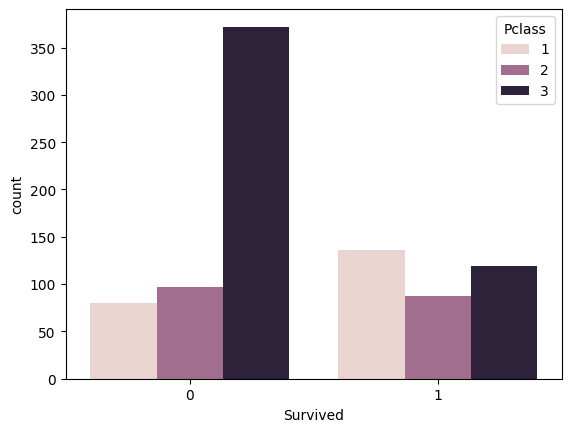

In [129]:
# plot of Survived grouped by pclass
sns.countplot(data=df_train, x='Survived', hue='Pclass')


## ***4.3 : Sex***

Count of females who survived: 233
Count of females who did not survive: 81
--------------------------------------------
Count of males who survived: 109
Count of males who did not survive: 468


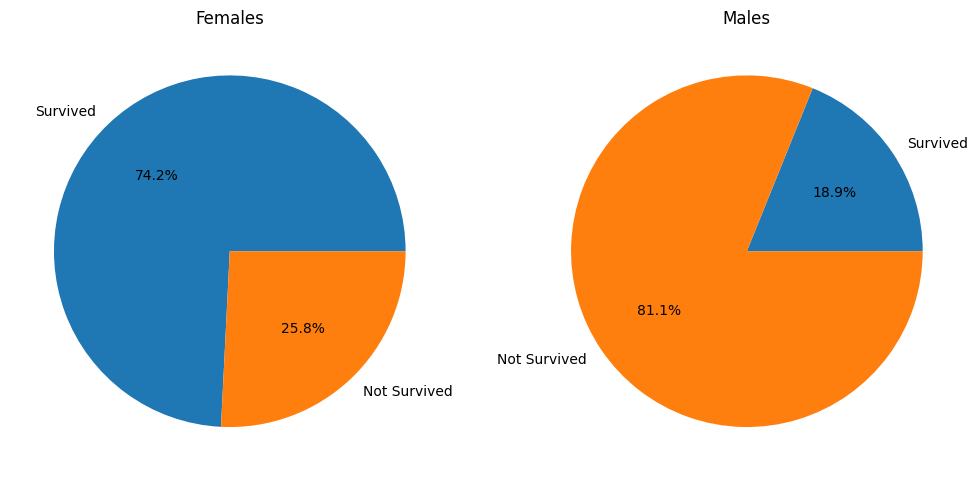

In [130]:
# Count of females who survived and did not survive
female_survived_count = df_train[(df_train['Sex'] == 'female') & (df_train['Survived'] == 1)].shape[0]
female_not_survived_count = df_train[(df_train['Sex'] == 'female') & (df_train['Survived'] == 0)].shape[0]

# Count of males who survived and did not survive
male_survived_count = df_train[(df_train['Sex'] == 'male') & (df_train['Survived'] == 1)].shape[0]
male_not_survived_count = df_train[(df_train['Sex'] == 'male') & (df_train['Survived'] == 0)].shape[0]

print("Count of females who survived:", female_survived_count)
print("Count of females who did not survive:", female_not_survived_count)
print("--------------------------------------------")
print("Count of males who survived:", male_survived_count)
print("Count of males who did not survive:", male_not_survived_count)

# plot
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
labels = ['Survived', 'Not Survived']
sizes = [female_survived_count, female_not_survived_count]
plt.pie(sizes, labels=labels, autopct='%1.1f%%')
plt.title('Females')

# Pie plot for males
plt.subplot(1, 2, 2)
sizes = [male_survived_count, male_not_survived_count]
plt.pie(sizes, labels=labels, autopct='%1.1f%%')
plt.title('Males')

plt.tight_layout()
plt.show()

>*  Female survived `74.2%` and male `18.9%`
>*  Female non survived `25.8%` and male `81.9%`

## ***4.4 : Age***

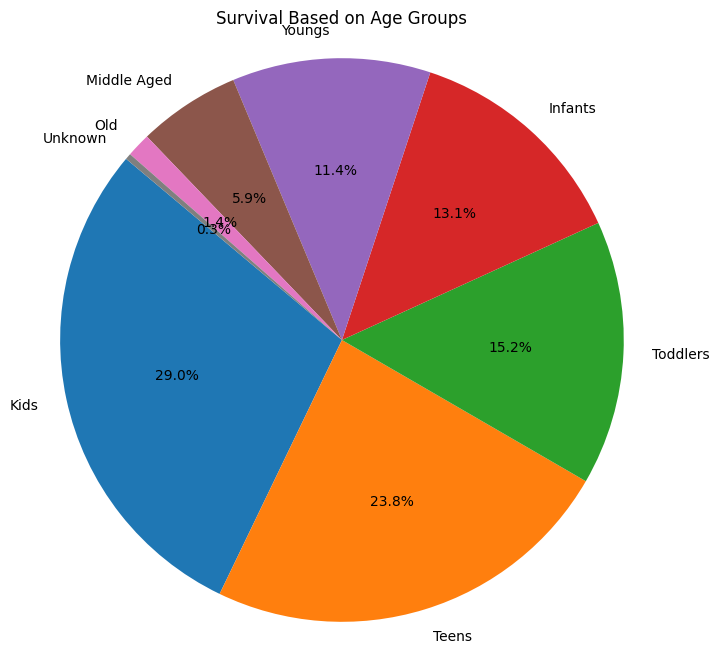

In [131]:
import matplotlib.pyplot as plt
import pandas as pd

# Assuming df_train contains the necessary data

# Define age groups
age_bins = [0, 10, 20, 30, 40, 50, 60, 70, 80]
age_labels = ['Infants', 'Toddlers', 'Kids', 'Teens', 'Youngs', 'Middle Aged', 'Old', 'Unknown']  # Add 'Unknown' for values outside the defined bins
# Categorize ages into groups
df_train['AgeGroup'] = pd.cut(df_train['Age'], bins=age_bins, labels=age_labels)

# Count survivors in each age group
survivors_by_age_group = df_train[df_train['Survived'] == 1]['AgeGroup'].value_counts()
# test data
# Define age groups
age_bins = [0, 10, 20, 30, 40, 50, 60, 70, 80]
age_labels = ['Infants', 'Toddlers', 'Kids', 'Teens', 'Youngs', 'Middle Aged', 'Old', 'Unknown']  # Add 'Unknown' for values outside the defined bins
# Categorize ages into groups
df_test['AgeGroup'] = pd.cut(df_test['Age'], bins=age_bins, labels=age_labels)

# Count survivors in each age group
survivors_by_age_group = df_train[df_train['Survived'] == 1]['AgeGroup'].value_counts()

# Plot
plt.figure(figsize=(8, 8))
plt.pie(survivors_by_age_group, labels=survivors_by_age_group.index, autopct='%1.1f%%', startangle=140)
plt.title('Survival Based on Age Groups')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()


## ***4.5 : SibSp***

In [132]:
df_train['SibSp'].value_counts()

,count
SibSp,
0,608
1,209
2,28
4,18
3,16
8,7
5,5


Percentage of SibSp = 0 who survived: 34.53947368421053
Percentage of SibSp = 1 who survived: 53.588516746411486
Percentage of SibSp = 2 who survived: 46.42857142857143
Percentage of SibSp = 3 who survived: 25.0
Percentage of SibSp = 4 who survived: 16.666666666666664


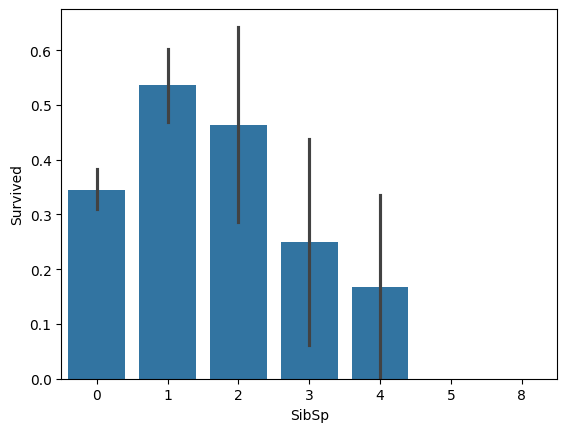

In [133]:
#draw a bar plot for SibSp vs. survival
sns.barplot(x="SibSp", y="Survived", data=df_train)

#I won't be printing individual percent values for all of these.
print("Percentage of SibSp = 0 who survived:", df_train["Survived"][df_train["SibSp"] == 0].value_counts(normalize = True)[1]*100)

print("Percentage of SibSp = 1 who survived:", df_train["Survived"][df_train["SibSp"] == 1].value_counts(normalize = True)[1]*100)

print("Percentage of SibSp = 2 who survived:", df_train["Survived"][df_train["SibSp"] == 2].value_counts(normalize = True)[1]*100)

print("Percentage of SibSp = 3 who survived:", df_train["Survived"][df_train["SibSp"] == 3].value_counts(normalize = True)[1]*100)

print("Percentage of SibSp = 4 who survived:", df_train["Survived"][df_train["SibSp"] == 4].value_counts(normalize = True)[1]*100)


>* It's clear that people with more siblings or spouses aboard were less likely to survive.

## ***4.6 : Embarked***

<Figure size 800x600 with 0 Axes>

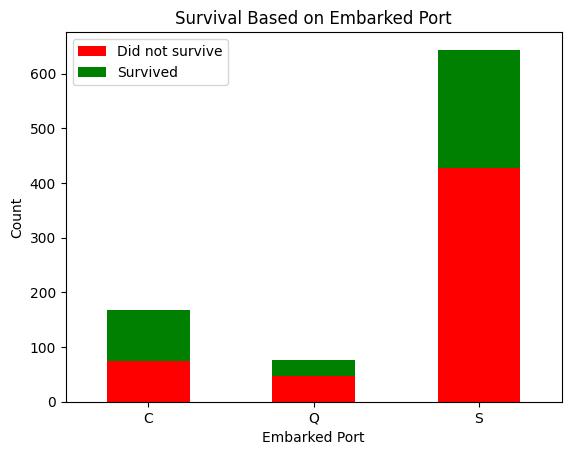

In [134]:
# Grouping data by 'Embarked' and 'Survived', and calculating the count of passengers
survivors_by_embarked = df_train.groupby(['Embarked', 'Survived']).size().unstack()

# Plot
plt.figure(figsize=(8, 6))
survivors_by_embarked.plot(kind='bar', stacked=True, color=['red', 'green'])
plt.title('Survival Based on Embarked Port')
plt.xlabel('Embarked Port')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend(['Did not survive', 'Survived'], loc='upper left')
plt.show()

In [135]:
# Assuming df_train contains the necessary data

# Count survivors based on embarked port
survived_by_embarked = df_train[df_train['Survived'] == 1]['Embarked'].value_counts()

print("Survived based on embarked port:")
print(survived_by_embarked)
print("-------------------------------------")
# Count non-survivors based on embarked port
non_survived_by_embarked = df_train[df_train['Survived'] == 0]['Embarked'].value_counts()

print("Non-survival based on embarked port:")
print(non_survived_by_embarked)


Survived based on embarked port:
Embarked
S    217
C     93
Q     30
Name: count, dtype: int64
-------------------------------------
Non-survival based on embarked port:
Embarked
S    427
C     75
Q     47
Name: count, dtype: int64


>* Mostly people survived of `S = Southampton`
>* MOstly people non survived also `S = Southampton`

## ***4.7 : Fare***

In [136]:
# scatter plot age and fare base on survived in plotly
fig = px.scatter(df_train, x='Age', y='Fare', color='Survived', title='Age vs Fare')
fig.show()

<a id="miss"></a>
<span style="color: red; font-size: 250%; font-weight: bold;">Step 5 | Check Missing Values</span>


<Axes: >

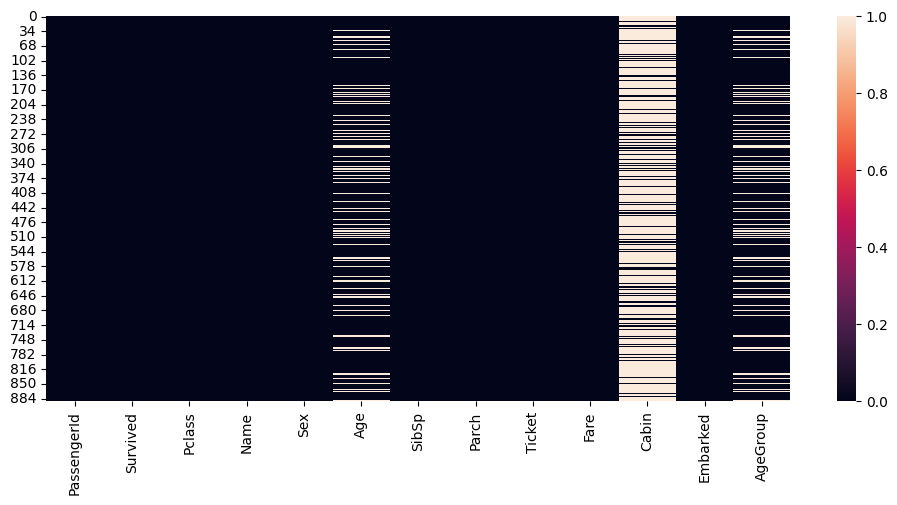

In [137]:
# check null values of train data by graphically

plt.figure(figsize=(12,5))
sns.heatmap(df_train.isnull())

<Axes: >

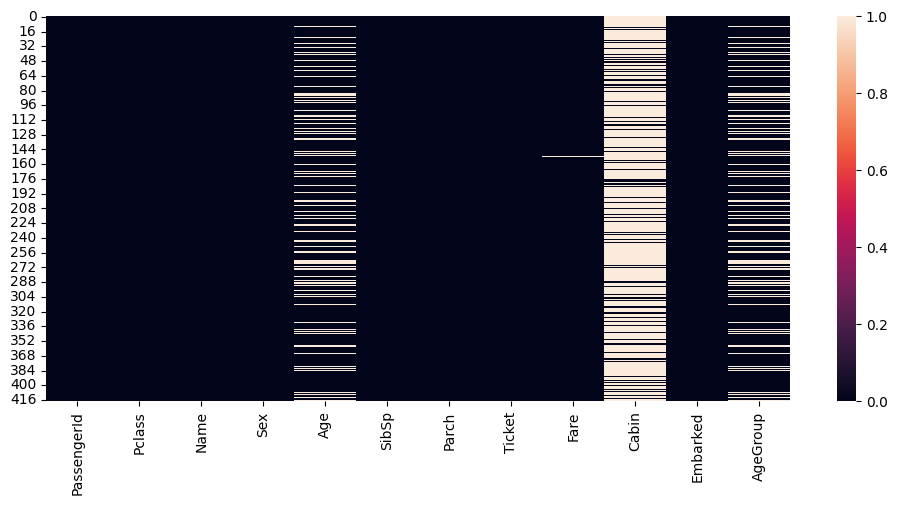

In [138]:
# check null values of test data by graphically

plt.figure(figsize=(12,5))
sns.heatmap(df_test.isnull())

In [139]:
# check null values in train data by using pandas
df_train.isnull().sum().sort_values(ascending=False)

,0
Cabin,687
Age,177
AgeGroup,177
Embarked,2
PassengerId,0
Sex,0
Name,0
Pclass,0
Survived,0
Ticket,0


`IN TRAIN DATA`
>* `Cabin column` have `687` missing values
>* `Age column` have `177` missing values
>* `Embarkd column` have `2` missing values


In [140]:
# check null values in test data by using pandas
df_test.isnull().sum().sort_values(ascending=False)

,0
Cabin,327
Age,86
AgeGroup,86
Fare,1
Sex,0
Name,0
Pclass,0
PassengerId,0
Ticket,0
Parch,0


`IN TEST DATA`
>* `Cabin column` have `327` missing values
>* `Age column` have `86` missing values
>* `Fare column` have `1` missing values


In [141]:
# percentage of null values
percentage=(df_train.isnull().sum().sort_values(ascending=False)/len(df_train))*100
percentage

,0
Cabin,77.104377
Age,19.865320
AgeGroup,19.865320
Embarked,0.224467
PassengerId,0.000000
Sex,0.000000
Name,0.000000
Pclass,0.000000
Survived,0.000000
Ticket,0.000000


In [142]:
# percentage of null values
percentage=(df_test.isnull().sum().sort_values(ascending=False)/len(df_train))*100
percentage

,0
Cabin,36.700337
Age,9.652076
AgeGroup,9.652076
Fare,0.112233
Sex,0.000000
Name,0.000000
Pclass,0.000000
PassengerId,0.000000
Ticket,0.000000
Parch,0.000000


<a id="impute"></a>
<span style="color: red; font-size: 250%; font-weight: bold;">Step 6 | Impute Missing Values</span>

## `Train Data`

In [143]:
missing_data_cols = df_train.isnull().sum()[df_train.isnull().sum() > 0].index.tolist()
print("Columns  of missing values in train data :",missing_data_cols)

Columns  of missing values in train data : ['Age', 'Cabin', 'Embarked', 'AgeGroup']


In [144]:
# Cabin column  in train data have highest missing values so removed
df_train.drop('Cabin', axis=1, inplace=True)

> * `Cabin` have more than `50%` missing values in `train data` so removed from data

In [145]:
categorical_cols = ["Embarked",'AgeGroup']
bool_cols = []
numeric_cols = ["Age"]
missing_data_cols = df_train.isnull().sum()[df_train.isnull().sum() > 0].index.tolist()

In [146]:
df=df_train.copy()

In [147]:

# define the function to impute the missing values

def impute_categorical_missing_data(passed_col):

    df_null = df[df[passed_col].isnull()]
    df_not_null = df[df[passed_col].notnull()]

    X = df_not_null.drop(passed_col, axis=1)
    y = df_not_null[passed_col]

    other_missing_cols = [col for col in missing_data_cols if col != passed_col]

    label_encoder = LabelEncoder()

    for col in X.columns:
        if X[col].dtype == 'object' or X[col].dtype == 'category':
            X[col] = label_encoder.fit_transform(X[col])

    if passed_col in bool_cols:
        y = label_encoder.fit_transform(y)

    iterative_imputer = IterativeImputer(estimator=RandomForestRegressor(random_state=42), add_indicator=True)

    for col in other_missing_cols:
        if X[col].isnull().sum() > 0:
            col_with_missing_values = X[col].values.reshape(-1, 1)
            imputed_values = iterative_imputer.fit_transform(col_with_missing_values)
            X[col] = imputed_values[:, 0]
        else:
            pass

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    rf_classifier = RandomForestClassifier()

    rf_classifier.fit(X_train, y_train)

    y_pred = rf_classifier.predict(X_test)

    acc_score = accuracy_score(y_test, y_pred)

    print("The feature '"+ passed_col+ "' has been imputed with", round((acc_score * 100), 2), "accuracy\n")

    X = df_null.drop(passed_col, axis=1)

    for col in X.columns:
        if X[col].dtype == 'object' or X[col].dtype == 'category':
            X[col] = label_encoder.fit_transform(X[col])

    for col in other_missing_cols:
        if X[col].isnull().sum() > 0:
            col_with_missing_values = X[col].values.reshape(-1, 1)
            imputed_values = iterative_imputer.fit_transform(col_with_missing_values)
            X[col] = imputed_values[:, 0]
        else:
            pass

    if len(df_null) > 0:
        df_null[passed_col] = rf_classifier.predict(X)
        if passed_col in bool_cols:
            df_null[passed_col] = df_null[passed_col].map({0: False, 1: True})
        else:
            pass
    else:
        pass

    df_combined = pd.concat([df_not_null, df_null])

    return df_combined[passed_col]

def impute_continuous_missing_data(passed_col):

    df_null = df[df[passed_col].isnull()]
    df_not_null = df[df[passed_col].notnull()]

    X = df_not_null.drop(passed_col, axis=1)
    y = df_not_null[passed_col]

    other_missing_cols = [col for col in missing_data_cols if col != passed_col]

    label_encoder = LabelEncoder()

    for col in X.columns:
        if X[col].dtype == 'object' or X[col].dtype == 'category':
            X[col] = label_encoder.fit_transform(X[col])

    iterative_imputer = IterativeImputer(estimator=RandomForestRegressor(random_state=42), add_indicator=True)

    for col in other_missing_cols:
        if X[col].isnull().sum() > 0:
            col_with_missing_values = X[col].values.reshape(-1, 1)
            imputed_values = iterative_imputer.fit_transform(col_with_missing_values)
            X[col] = imputed_values[:, 0]
        else:
            pass

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    rf_regressor = RandomForestRegressor()

    rf_regressor.fit(X_train, y_train)

    y_pred = rf_regressor.predict(X_test)

    print("MAE =", mean_absolute_error(y_test, y_pred), "\n")
    print("RMSE =", mean_squared_error(y_test, y_pred, squared=False), "\n")
    print("R2 =", r2_score(y_test, y_pred), "\n")

    X = df_null.drop(passed_col, axis=1)

    for col in X.columns:
        if X[col].dtype == 'object' or X[col].dtype == 'category':
            X[col] = label_encoder.fit_transform(X[col])

    for col in other_missing_cols:
        if X[col].isnull().sum() > 0:
            col_with_missing_values = X[col].values.reshape(-1, 1)
            imputed_values = iterative_imputer.fit_transform(col_with_missing_values)
            X[col] = imputed_values[:, 0]
        else:
            pass

    if len(df_null) > 0:
        df_null[passed_col] = rf_regressor.predict(X)
    else:
        pass

    df_combined = pd.concat([df_not_null, df_null])

    return df_combined[passed_col]

In [148]:
def impute_categorical_missing_data(passed_col):

    df_null = df[df[passed_col].isnull()]
    df_not_null = df[df[passed_col].notnull()]

    X = df_not_null.drop(passed_col, axis=1)
    y = df_not_null[passed_col]

    other_missing_cols = [col for col in missing_data_cols if col != passed_col]

    label_encoder = LabelEncoder()

    for col in X.columns:
        if X[col].dtype == 'object' or X[col].dtype == 'category':
            X[col] = label_encoder.fit_transform(X[col])

    if passed_col in bool_cols:
        y = label_encoder.fit_transform(y)

    iterative_imputer = IterativeImputer(estimator=RandomForestRegressor(random_state=42), add_indicator=True)

    for col in other_missing_cols:
        if X[col].isnull().sum() > 0:
            col_with_missing_values = X[col].values.reshape(-1, 1)
            imputed_values = iterative_imputer.fit_transform(col_with_missing_values)
            X[col] = imputed_values[:, 0]
        else:
            pass

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    rf_classifier = RandomForestClassifier()

    rf_classifier.fit(X_train, y_train)

    y_pred = rf_classifier.predict(X_test)

    acc_score = accuracy_score(y_test, y_pred)

    print("The feature '"+ passed_col+ "' has been imputed with", round((acc_score * 100), 2), "accuracy\n")

    X = df_null.drop(passed_col, axis=1)

    for col in X.columns:
        if X[col].dtype == 'object' or X[col].dtype == 'category':
            X[col] = label_encoder.fit_transform(X[col])

    for col in other_missing_cols:
        if X[col].isnull().sum() > 0:
            col_with_missing_values = X[col].values.reshape(-1, 1)
            imputed_values = iterative_imputer.fit_transform(col_with_missing_values)
            X[col] = imputed_values[:, 0]
        else:
            pass

    if len(df_null) > 0:
        df_null[passed_col] = rf_classifier.predict(X)
        if passed_col in bool_cols:
            df_null[passed_col] = df_null[passed_col].map({0: False, 1: True})
        else:
            pass
    else:
        pass

    df_combined = pd.concat([df_not_null, df_null])

    return df_combined[passed_col]

def impute_continuous_missing_data(passed_col):

    df_null = df[df[passed_col].isnull()]
    df_not_null = df[df[passed_col].notnull()]

    X = df_not_null.drop(passed_col, axis=1)
    y = df_not_null[passed_col]

    other_missing_cols = [col for col in missing_data_cols if col != passed_col]

    label_encoder = LabelEncoder()

    for col in X.columns:
        if X[col].dtype == 'object' or X[col].dtype == 'category':
            X[col] = label_encoder.fit_transform(X[col])

    iterative_imputer = IterativeImputer(estimator=RandomForestRegressor(random_state=42), add_indicator=True)

    for col in other_missing_cols:
        if X[col].isnull().sum() > 0:
            col_with_missing_values = X[col].values.reshape(-1, 1)
            imputed_values = iterative_imputer.fit_transform(col_with_missing_values)
            X[col] = imputed_values[:, 0]
        else:
            pass

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    rf_regressor = RandomForestRegressor()

    rf_regressor.fit(X_train, y_train)

    y_pred = rf_regressor.predict(X_test)

    print("MAE =", mean_absolute_error(y_test, y_pred), "\n")
    print("RMSE =", np.sqrt(mean_squared_error(y_test, y_pred)), "\n")
    print("R2 =", r2_score(y_test, y_pred), "\n")

    X = df_null.drop(passed_col, axis=1)

    for col in X.columns:
        if X[col].dtype == 'object' or X[col].dtype == 'category':
            X[col] = label_encoder.fit_transform(X[col])

    for col in other_missing_cols:
        if X[col].isnull().sum() > 0:
            col_with_missing_values = X[col].values.reshape(-1, 1)
            imputed_values = iterative_imputer.fit_transform(col_with_missing_values)
            X[col] = imputed_values[:, 0]
        else:
            pass

    if len(df_null) > 0:
        df_null[passed_col] = rf_regressor.predict(X)
    else:
        pass

    df_combined = pd.concat([df_not_null, df_null])

    return df_combined[passed_col]

# impute missing values using our functions
for col in missing_data_cols:
    print("Missing Values", col, ":", str(round((df[col].isnull().sum() / len(df)) * 100, 2))+"%")
    if col in categorical_cols:
        df[col] = impute_categorical_missing_data(col)
    elif col in numeric_cols:
        df[col] = impute_continuous_missing_data(col)
    else:

        pass

Missing Values Age : 19.87%
MAE = 2.3731076923076917 

RMSE = 2.8853401400486955 

R2 = 0.9550970922309463 

Missing Values Embarked : 0.22%
The feature 'Embarked' has been imputed with 88.2 accuracy

Missing Values AgeGroup : 19.87%
The feature 'AgeGroup' has been imputed with 95.1 accuracy



## `Test Data`

In [149]:
# Cabin column  in test data have highest missing values so removed
df_test.drop('Cabin', axis=1, inplace=True)

In [150]:
df_test.isnull().sum()

,0
PassengerId,0
Pclass,0
Name,0
Sex,0
Age,86
SibSp,0
Parch,0
Ticket,0
Fare,1
Embarked,0


In [151]:
categorical_cols = []
bool_cols = []
numeric_cols = ["Age", "Fare"]
missing_data_cols = df_test.isnull().sum()[df_test.isnull().sum() > 0].index.tolist()


In [152]:
# df=df_test.copy()


In [153]:

# define the function to impute the missing values

def impute_categorical_missing_data(passed_col):

    df_null = df[df[passed_col].isnull()]
    df_not_null = df[df[passed_col].notnull()]

    X = df_not_null.drop(passed_col, axis=1)
    y = df_not_null[passed_col]

    other_missing_cols = [col for col in missing_data_cols if col != passed_col]

    label_encoder = LabelEncoder()

    for col in X.columns:
        if X[col].dtype == 'object' or X[col].dtype == 'category':
            X[col] = label_encoder.fit_transform(X[col])

    if passed_col in bool_cols:
        y = label_encoder.fit_transform(y)

    iterative_imputer = IterativeImputer(estimator=RandomForestRegressor(random_state=42), add_indicator=True)

    for col in other_missing_cols:
        if X[col].isnull().sum() > 0:
            col_with_missing_values = X[col].values.reshape(-1, 1)
            imputed_values = iterative_imputer.fit_transform(col_with_missing_values)
            X[col] = imputed_values[:, 0]
        else:
            pass

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    rf_classifier = RandomForestClassifier()

    rf_classifier.fit(X_train, y_train)

    y_pred = rf_classifier.predict(X_test)

    acc_score = accuracy_score(y_test, y_pred)

    print("The feature '"+ passed_col+ "' has been imputed with", round((acc_score * 100), 2), "accuracy\n")

    X = df_null.drop(passed_col, axis=1)

    for col in X.columns:
        if X[col].dtype == 'object' or X[col].dtype == 'category':
            X[col] = label_encoder.fit_transform(X[col])

    for col in other_missing_cols:
        if X[col].isnull().sum() > 0:
            col_with_missing_values = X[col].values.reshape(-1, 1)
            imputed_values = iterative_imputer.fit_transform(col_with_missing_values)
            X[col] = imputed_values[:, 0]
        else:
            pass

    if len(df_null) > 0:
        df_null[passed_col] = rf_classifier.predict(X)
        if passed_col in bool_cols:
            df_null[passed_col] = df_null[passed_col].map({0: False, 1: True})
        else:
            pass
    else:
        pass

    df_combined = pd.concat([df_not_null, df_null])

    return df_combined[passed_col]

def impute_continuous_missing_data(passed_col):

    df_null = df[df[passed_col].isnull()]
    df_not_null = df[df[passed_col].notnull()]

    X = df_not_null.drop(passed_col, axis=1)
    y = df_not_null[passed_col]

    other_missing_cols = [col for col in missing_data_cols if col != passed_col]

    label_encoder = LabelEncoder()

    for col in X.columns:
        if X[col].dtype == 'object' or X[col].dtype == 'category':
            X[col] = label_encoder.fit_transform(X[col])

    iterative_imputer = IterativeImputer(estimator=RandomForestRegressor(random_state=42), add_indicator=True)

    for col in other_missing_cols:
        if X[col].isnull().sum() > 0:
            col_with_missing_values = X[col].values.reshape(-1, 1)
            imputed_values = iterative_imputer.fit_transform(col_with_missing_values)
            X[col] = imputed_values[:, 0]
        else:
            pass

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    rf_regressor = RandomForestRegressor()

    rf_regressor.fit(X_train, y_train)

    y_pred = rf_regressor.predict(X_test)

    print("MAE =", mean_absolute_error(y_test, y_pred), "\n")
    print("RMSE =", np.sqrt(mean_squared_error(y_test, y_pred)), "\n")
    print("R2 =", r2_score(y_test, y_pred), "\n")

    X = df_null.drop(passed_col, axis=1)

    for col in X.columns:
        if X[col].dtype == 'object' or X[col].dtype == 'category':
            X[col] = label_encoder.fit_transform(X[col])

    for col in other_missing_cols:
        if X[col].isnull().sum() > 0:
            col_with_missing_values = X[col].values.reshape(-1, 1)
            imputed_values = iterative_imputer.fit_transform(col_with_missing_values)
            X[col] = imputed_values[:, 0]
        else:
            pass

    if len(df_null) > 0:
        df_null[passed_col] = rf_regressor.predict(X)
    else:
        pass

    df_combined = pd.concat([df_not_null, df_null])

    return df_combined[passed_col]

In [154]:
# impute missing values using our functions
for col in missing_data_cols:
    print("Missing Values", col, ":", str(round((df_test[col].isnull().sum() / len(df_test)) * 100, 2))+"%")
    if col in categorical_cols:
        df_test[col] = impute_categorical_missing_data(col)
    elif col in numeric_cols:
        df_test[col] = impute_continuous_missing_data(col)
    else:
        pass

Missing Values Age : 20.57%
MAE = 3.3189998938547483 

RMSE = 4.237183682257719 

R2 = 0.9402605199530256 

Missing Values Fare : 0.24%
MAE = 13.974014463687142 

RMSE = 37.215341841810535 

R2 = 0.1049792177870622 

Missing Values AgeGroup : 20.57%


## ***All missing values imputed***

<a id="outlier"></a>
<span style="color: red; font-size: 250%; font-weight: bold;">Step 7 | Outliers</span>

`TRAIN DATA`

In [155]:
# Remove outliers from Age column in train data removed outliers greater than 70
df_train = df_train[df_train['Age'] < 70]
# remove outliers from Fare column in train data removed outliers greater than 500
df_train = df_train[df_train['Fare'] < 500]

<a id="ml"></a>
<span style="color: red; font-size: 250%; font-weight: bold;">Step 8 | Machine Learning</span>

##  ***8.1 : Features Selection***

>* `Name` ,`Ticket` and `AgeGroup` column are not necessary or valuable for train the model so removed

In [156]:
df_test.head(2)

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,AgeGroup
0,892,3,"Kelly, Mr. James",male,22.0,0,0,330911,7.2500,Q,Teens
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,38.0,1,0,363272,71.2833,S,Youngs


In [157]:
df_train.drop(['Name','Ticket','AgeGroup'],axis=1,inplace=True)
df_test.drop(['Name','Ticket','AgeGroup'],axis=1,inplace=True)

In [158]:
# encode the categorical columns
le = LabelEncoder()
for col in df_train.columns:
    if df_train[col].dtypes == 'object' or df_train[col].dtypes == 'category':
        df_train[col] = le.fit_transform(df_train[col])
# encode the categorical columns
le = LabelEncoder()
for col in df_test.columns:
    if df_test[col].dtypes == 'object' or df_test[col].dtypes == 'category':
        df_test[col] = le.fit_transform(df_test[col])

In [159]:
X = df_train.drop(['Survived','PassengerId'],axis=1)
y = df_train['Survived']

In [160]:
X_train,X_test,y_train,y_test=train_test_split(X, y, test_size=0.2, random_state=42)

<a id="random"></a>
## ***8.2 : RandomForestClassifier***

In [161]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix, f1_score, precision_score, accuracy_score

# Define the pipeline with a scaler and the random forest classifier
pipeline = Pipeline([
    ('scaler', MinMaxScaler()),
    ('classifier', RandomForestClassifier(random_state=42))
])

# Define the hyperparameters for grid search
params = {
    'classifier__n_estimators': [100, 200, 300],
    'classifier__max_depth': [10, 20, 30]
}

# Perform grid search using the pipeline and parameters
clf = GridSearchCV(pipeline, params, cv=5)
clf.fit(X_train, y_train)

# Get the best model and its parameters
best_model = clf.best_estimator_
best_model.fit(X_train, y_train)
y_pred_best = best_model.predict(X_test)
accuracy_best = accuracy_score(y_test, y_pred_best)
conf_matrix = confusion_matrix(y_test, y_pred_best)
f1 = f1_score(y_test, y_pred_best)
precision = precision_score(y_test, y_pred_best)

# Print the results
print("Best Random Forest Model:")
print("Test Accuracy:", accuracy_best)
print("F1 Score:", f1)
print("Precision Score:", precision)
print("------------------------------------------")
print("Confusion Matrix:",conf_matrix)



Best Random Forest Model:
Test Accuracy: 0.8297872340425532
F1 Score: 0.76
Precision Score: 0.8444444444444444
------------------------------------------
Confusion Matrix: [[79  7]
 [17 38]]


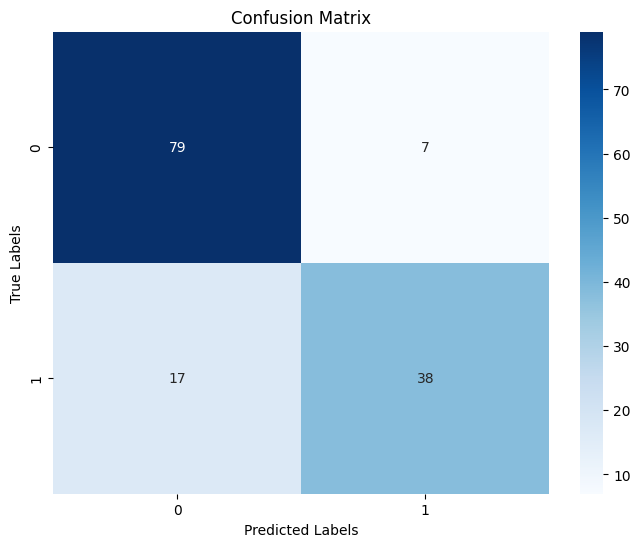

In [162]:
# create confusion plot for best model
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, cmap='Blues', fmt='g')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

<a id="submission"></a>

<span style="color: red; font-size: 250%; font-weight: bold;">Step 9 | Submission</span>


In [163]:
#set ids as PassengerId and predict survival
ids = df_test['PassengerId']
predictions = best_model.predict(df_test.drop('PassengerId', axis=1))

#set the output as a dataframe and convert to csv file named submission.csv
output = pd.DataFrame({ 'PassengerId' : ids, 'Survived': predictions })
output.to_csv('submission.csv', index=False)